# Notebook to compute the evaluate the camera accuracy 



In [40]:
from pathlib import Path
import sys
import cv2
import matplotlib.pyplot as plt
import numpy as np
import yaml

for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "src" / "science_jubilee").is_dir():
        REPO_ROOT = parent
        break
else:
    raise RuntimeError("Could not locate the science_jubilee repository root")

SRC_ROOT = REPO_ROOT / "src"
for path in (SRC_ROOT, REPO_ROOT):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from science_jubilee.machine_session import MachineSession

def show(image, title=""):
    image_array = np.asarray(image)
    display_image = image_array if image_array.ndim == 3 else image_array
    plt.figure(figsize=(10, 7))
    plt.imshow(display_image, cmap="gray" if image_array.ndim == 2 else None)
    plt.title(title)
    plt.axis("off")
    plt.show()

hardware = False

First we go take a photo of the A4 sheet by trying to be centerd from it 

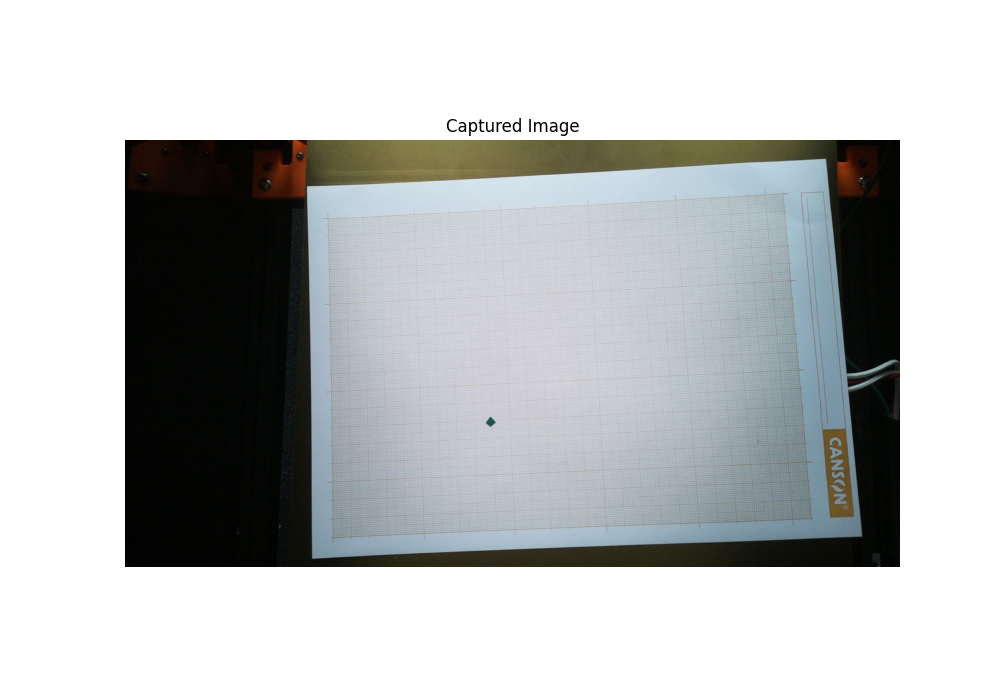

In [42]:
import time
import imageio
env = ".env.hardware"

    
session = MachineSession.from_env(env)
cam = session.camera
    
# move camera to imaging position and capture
X_DEPART, Y_DEPART, Z_DEPART = 130.0, 150.0, 320.0
cam.move_to_get_image(X_DEPART, Y_DEPART, Z_DEPART)

image = cam.get_image()
show(image, title="Captured Image") 


Détection de la cible noire avec Hough : on recherche le plus petit cercle visible et on l'affiche.

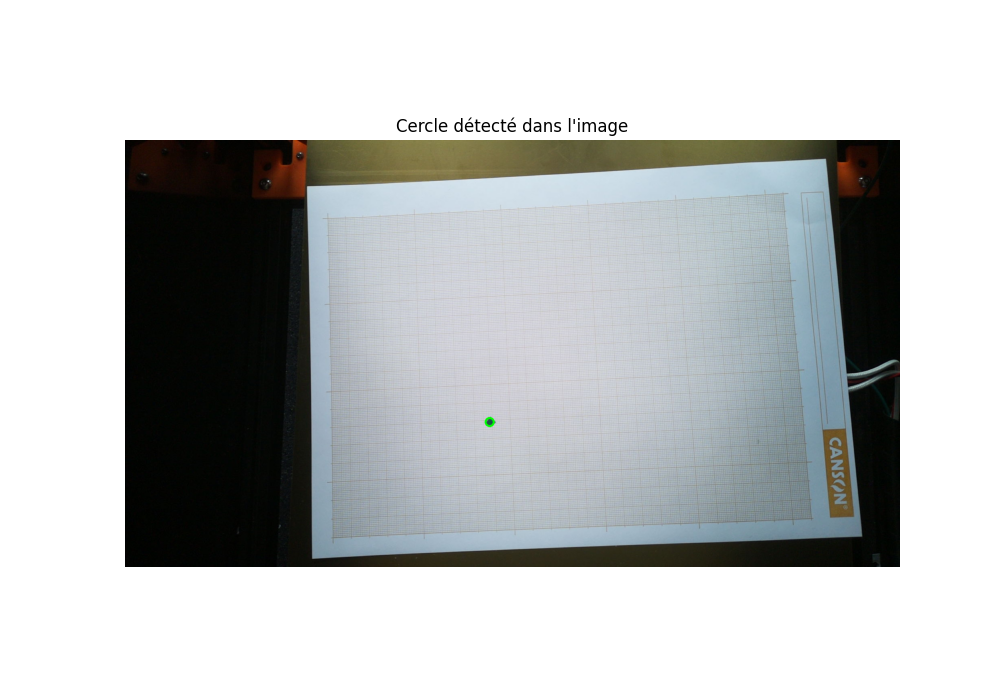

In [43]:
u_dot=float(903.38)   # valeurs a saissir avec votre selection sur l'image opencv
v_dot=float(697.17)
image_debug= image.copy()
cv2.circle(image_debug, (int(u_dot), int(v_dot)), 10, (0, 255, 0), 3)
show(image_debug, title="Cercle détecté dans l'image")

Green dot pixel: u=903.38, v=697.17 px
Green dot relative to camera: X=-12.78 mm, Y=33.06 mm, Z=320.00 mm
Camera-relative point [X, Y, Z] mm: [-12.77905477  33.05567741 320.        ]


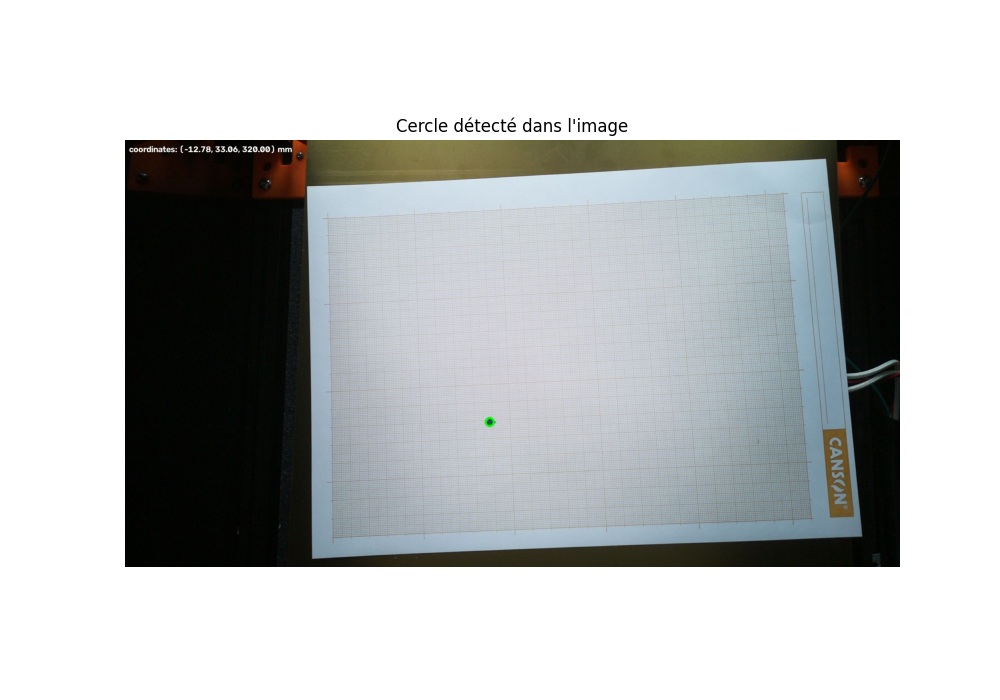

In [44]:
# Step 2: Convert the green-dot pixel to camera-relative coordinates
# Z_DEPART is the known camera-to-target depth in millimetres.
K = getattr(cam, "k", None)
if K is None:
    K = getattr(cam, "K", None)
dist = getattr(cam, "dist", None)

if K is None or dist is None:
    raise RuntimeError(
        "Camera calibration is missing. Expected cam.k/cam.dist "
        "or cam.K/cam.dist."
    )

K = np.asarray(K, dtype=np.float64)
dist = np.asarray(dist, dtype=np.float64)
if K.shape != (3, 3):
    raise ValueError(f"Expected a 3x3 camera matrix, got {K.shape}.")

# Undistort the detected pixel to normalized camera coordinates.
pixel = np.array([[[u_dot, v_dot]]], dtype=np.float64)
normalized_pixel = cv2.undistortPoints(pixel, K, dist)
x_normalized, y_normalized = normalized_pixel[0, 0]

z_camera_mm = float(Z_DEPART)
x_camera_mm = float(x_normalized * z_camera_mm)
y_camera_mm = float(y_normalized * z_camera_mm)
point_camera_mm = np.array(
    [x_camera_mm, y_camera_mm, z_camera_mm], dtype=np.float64
)

print(f"Green dot pixel: u={u_dot:.2f}, v={v_dot:.2f} px")
print(
    "Green dot relative to camera: "
    f"X={x_camera_mm:.2f} mm, "
    f"Y={y_camera_mm:.2f} mm, "
    f"Z={z_camera_mm:.2f} mm"
)
print(f"Camera-relative point [X, Y, Z] mm: {point_camera_mm}")
image_debug= image.copy()
cv2.circle(image_debug, (int(u_dot), int(v_dot)), 10, (0, 255, 0), 3)
cv2.putText(image_debug,f"coordinates: ({x_camera_mm:.2f}, {y_camera_mm:.2f}, {z_camera_mm:.2f}) mm", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
show(image_debug, title="Cercle détecté dans l'image")

Then we move our camera to the X and Y established


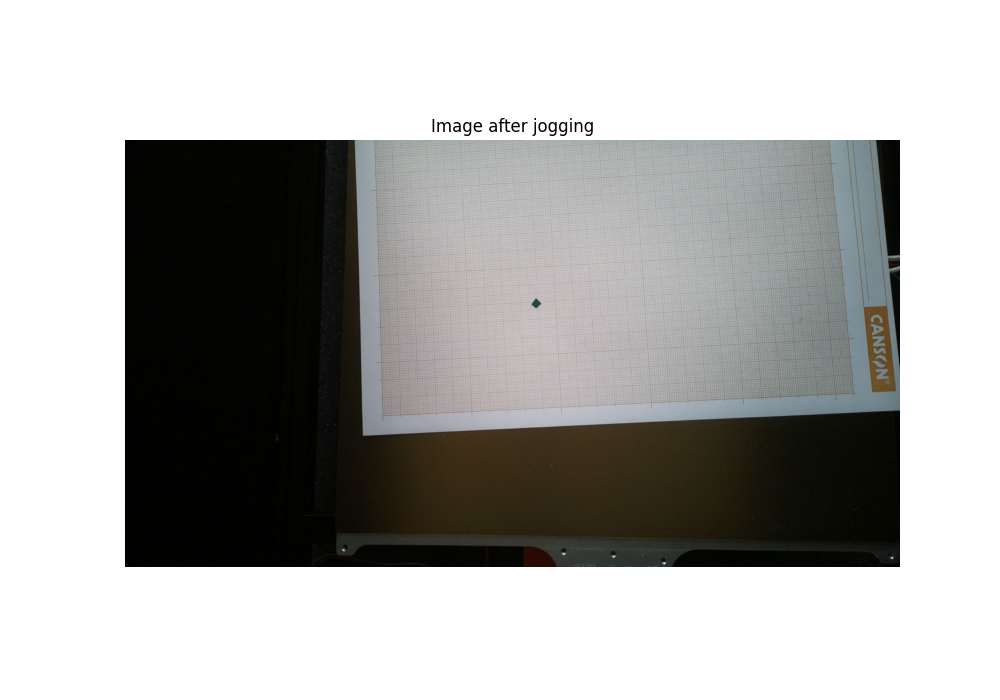

In [ ]:
nav= session.free_navigator

nav.move_to(
        x= X_DEPART+ x_camera_mm ,
        y= Y_DEPART-y_camera_mm ,
        speed=3000.0,
        wait=True,
    )
time.sleep(5.0)  # Wait for the motion to complete
image_2=cam.get_image()
show(image_2, title="Image after jogging")

Then we compute a line betwen the center of the camera and the green dot (that )

Calibration error: 4.64 px


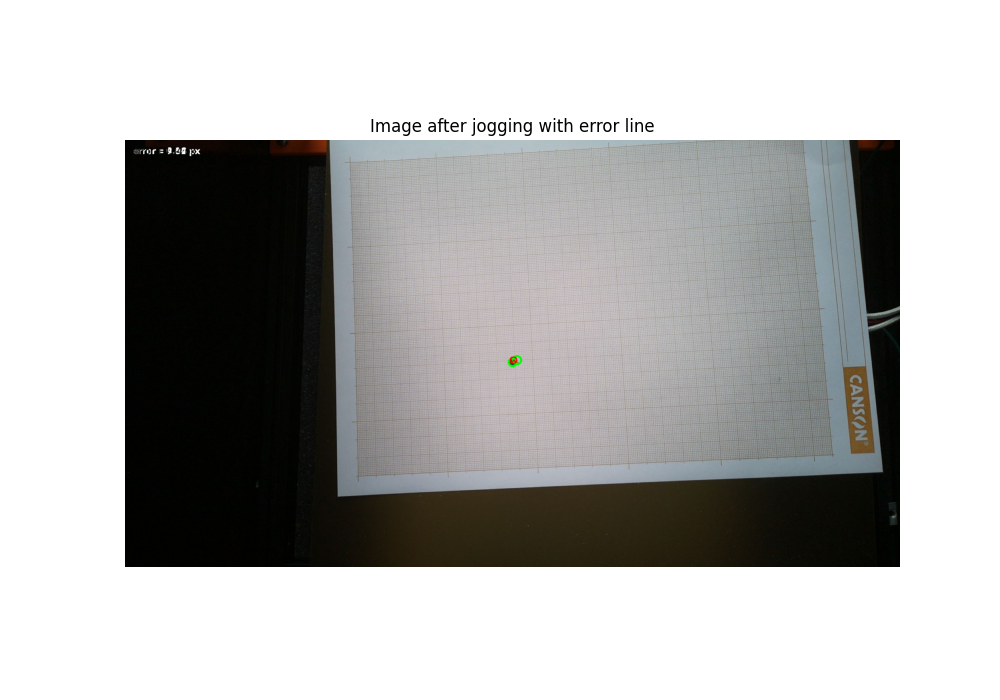

In [ ]:
u_dot_new = float(960.90)
v_dot_new = float(549.06)

# OpenCV drawing requires a writable, contiguous image buffer.
image2 = np.ascontiguousarray(image_2.copy())

# Compute the calibration error as the pixel distance from the image center.
cam_center_x = cam.K[0, 2]  # Use the principal point from the camera matrix
cam_center_y = cam.K[1, 2]  # Use the principal point from the camera matrix
error_px = float(np.hypot(u_dot_new - cam_center_x, v_dot_new - cam_center_y))

cv2.line(
    image2,
    (int(cam_center_x), int(cam_center_y)),
    (int(u_dot_new), int(v_dot_new)),
    (255, 0, 0),
    2,
)
cv2.circle(image2, (int(u_dot_new), int(v_dot_new)), 10, (0, 255, 0), 3)
cv2.circle(image2, (int(cam_center_x), int(cam_center_y)), 8, (255, 0, 0), 2)

error_label = f"error = {error_px:.2f} px"
cv2.putText(
    image2,
    error_label,
    (20, 35),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (255, 255, 255),
    3,
    cv2.LINE_AA,
)
cv2.putText(
    image2,
    error_label,
    (20, 35),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (0, 0, 0),
    1,
    cv2.LINE_AA,
)

print(f"Calibration error: {error_px:.2f} px")
show(image2, title="Image after jogging with error line")